In [1]:
import sys
sys.path.append("../src")

import time
import copy

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models

from dataset import (
    gather_samples, stratified_split, compute_class_weights,
    RiceLeafDataset, CLASSES
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
samples = gather_samples()
train_set, val_set, test_set = stratified_split(samples)
print("Train:", len(train_set), "Val:", len(val_set), "Test:", len(test_set))

class_weights = compute_class_weights(train_set)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

Train: 1927 Val: 413 Test: 413
Class weights: [0.6523358 1.3973894 0.9331719 0.5652684 1.591247  1.4800308 1.6484175]


In [4]:
BATCH_SIZE = 32
NUM_WORKERS = 4

train_ds = RiceLeafDataset(train_set, split="train")
val_ds = RiceLeafDataset(val_set, split="val")
test_ds = RiceLeafDataset(test_set, split="test")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Batches - train/val/test:", len(train_loader), len(val_loader), len(test_loader))

Batches - train/val/test: 61 13 13


In [5]:
NUM_CLASSES = len(CLASSES)

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=7, bias=True)
)


In [6]:
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

NUM_EPOCHS = 30
PATIENCE = 7

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [8]:
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"time={elapsed:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        torch.save(best_model_wts, "efficientnet_b0_best.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_wts)
print("Best val_loss:", best_val_loss)

Epoch 1/30 | train_loss=1.8452 train_acc=0.3010 | val_loss=1.7269 val_acc=0.3366 | time=33.6s
Epoch 2/30 | train_loss=1.5107 train_acc=0.4603 | val_loss=1.3562 val_acc=0.4891 | time=29.7s
Epoch 3/30 | train_loss=1.1959 train_acc=0.5750 | val_loss=1.0824 val_acc=0.6126 | time=28.7s
Epoch 4/30 | train_loss=0.9963 train_acc=0.6290 | val_loss=0.9012 val_acc=0.6634 | time=24.8s
Epoch 5/30 | train_loss=0.8786 train_acc=0.6912 | val_loss=0.8771 val_acc=0.6901 | time=27.6s
Epoch 6/30 | train_loss=0.7258 train_acc=0.7545 | val_loss=0.8131 val_acc=0.7433 | time=28.1s
Epoch 7/30 | train_loss=0.6668 train_acc=0.7686 | val_loss=0.8221 val_acc=0.7215 | time=27.2s
Epoch 8/30 | train_loss=0.6195 train_acc=0.7903 | val_loss=0.8159 val_acc=0.7288 | time=23.9s
Epoch 9/30 | train_loss=0.5826 train_acc=0.7971 | val_loss=0.7745 val_acc=0.7312 | time=27.7s
Epoch 10/30 | train_loss=0.5293 train_acc=0.8173 | val_loss=0.7544 val_acc=0.7361 | time=27.6s
Epoch 11/30 | train_loss=0.4878 train_acc=0.8313 | val_loss

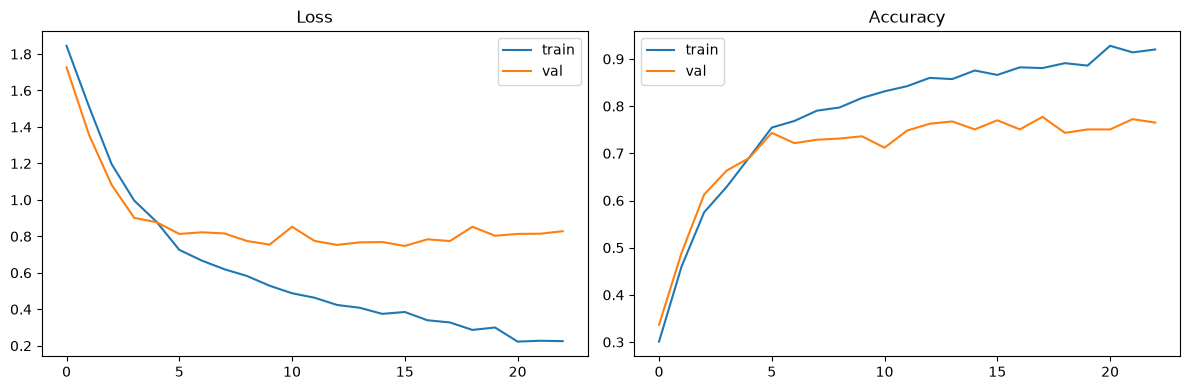

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Macro-F1:", f1_score(all_labels, all_preds, average="macro"))
print(classification_report(all_labels, all_preds, target_names=CLASSES))
print("Confusion matrix:\n", confusion_matrix(all_labels, all_preds))

Macro-F1: 0.7482642853793774
                 precision    recall  f1-score   support

        Healthy       0.86      0.91      0.89        90
         Insect       0.79      0.88      0.83        42
     Leaf Scald       0.73      0.71      0.72        63
     Rice Blast       0.92      0.88      0.90       105
Rice Leaffolder       0.67      0.86      0.75        37
   Rice Stripes       0.55      0.45      0.49        40
    Rice Tungro       0.75      0.58      0.66        36

       accuracy                           0.79       413
      macro avg       0.75      0.75      0.75       413
   weighted avg       0.79      0.79      0.79       413

Confusion matrix:
 [[82  4  0  1  2  1  0]
 [ 1 37  4  0  0  0  0]
 [ 0  0 45  0 10  6  2]
 [ 6  1  2 92  1  2  1]
 [ 0  2  2  0 32  1  0]
 [ 1  3  7  5  2 18  4]
 [ 5  0  2  2  1  5 21]]


In [11]:
import time as _time

num_params = sum(p.numel() for p in model.parameters())
print("Total params:", num_params)

model.eval()
dummy = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    for _ in range(5):
        model(dummy)
    start = _time.time()
    for _ in range(50):
        model(dummy)
    elapsed = _time.time() - start

print("Avg inference time (ms):", (elapsed / 50) * 1000)

Total params: 4016515
Avg inference time (ms): 8.437395095825195
